<a href="https://colab.research.google.com/github/alex-degarate/DAnalytics/blob/main/After_11/AC11_tips2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de correlación con "tips"

En la clase 10, habíamos introducido este tema a través del Dataset "tips" de Seaborn. Apliquemos entonces los conceptos vistos en clase.

In [ ]:
# Importamos librerías
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Cargamos la base de datos tips de Seaborn
tips = sns.load_dataset("tips")

# Visualizar las primeras filas del DataFrame
print(tips.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [ ]:
# Veamos algunos datos estadísticos
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


## EDA gráfico

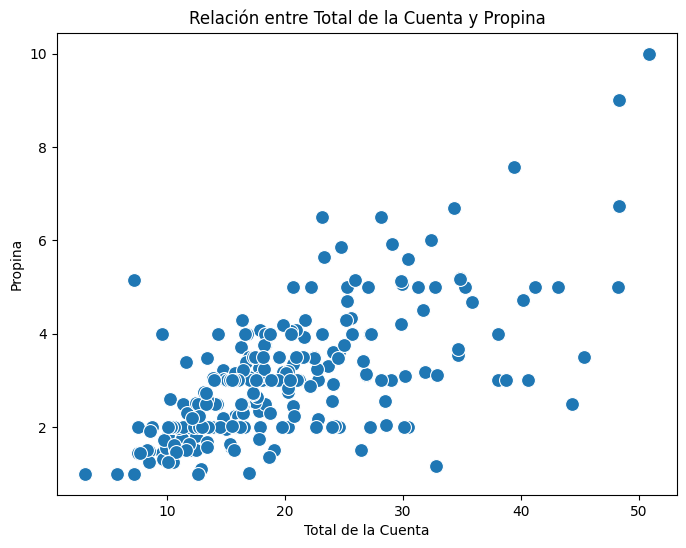

In [ ]:
# Hagamos un scatterplot
# Podemos agregar detalles pasando la variable categórica en el atributo hue
plt.figure(figsize=(8, 6))
sns.scatterplot(data=tips, x='total_bill', y='tip',  s=100)
plt.title('Relación entre Total de la Cuenta y Propina')
plt.xlabel('Total de la Cuenta')
plt.ylabel('Propina')
plt.show()

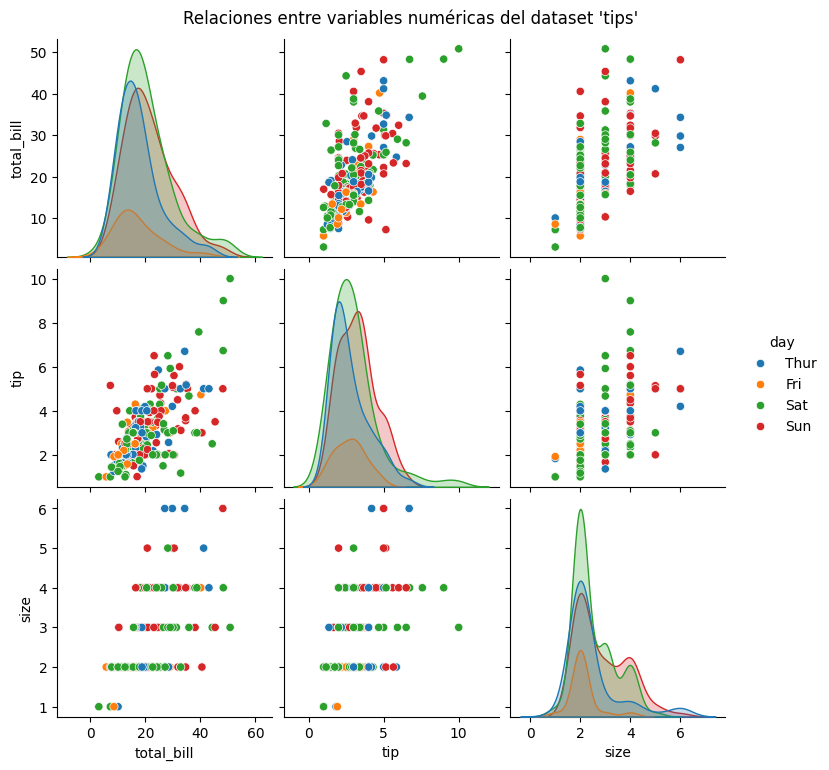

In [ ]:
# También podemos crear un pairplot solo con variables numéricas
# sns.pairplot(tips.select_dtypes(include='number'), diag_kind="hist")
sns.pairplot(tips, vars=["total_bill", "tip", "size"], hue="day")
plt.suptitle("Relaciones entre variables numéricas del dataset 'tips'", y=1.02)
plt.show()


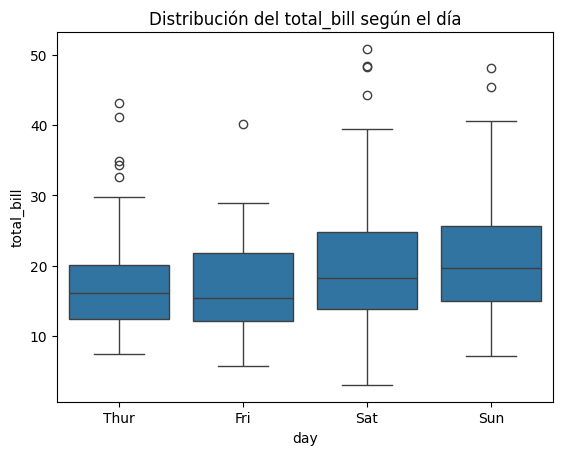

In [ ]:
# Para completar el EDA, agreguemos un Boxplot
sns.boxplot(data=tips, x="day", y="total_bill")
plt.title("Distribución del total_bill según el día")
plt.show()


## Correlación

In [ ]:
# Creamos la matriz de correlación
# Recordar que solo admite variables numericas, por lo que hay que filtrarlas
# tips_corr = tips.corr()
tips_corr = tips.select_dtypes(include=['number']).corr()
tips_corr

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


<Axes: >

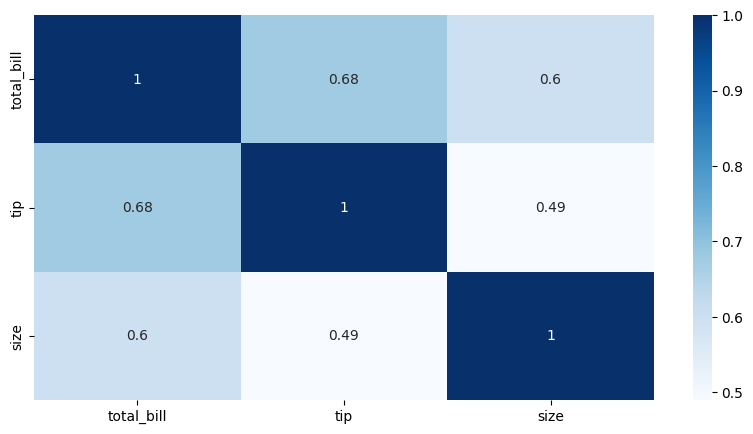

In [ ]:
# Usamos tips_corr para graficar un mapa de calor
plt.figure(figsize=(10, 5))
sns.heatmap(tips_corr, annot=True, cmap="Blues")